In [4]:
from app_store_scraper import AppStore
import pandas as pd

print("Libraries loaded successfully")

Libraries loaded successfully


In [5]:
# This creates an AppStore object that points to Robinhood's app
# country='us' means we're looking at the US App Store
# app_id is Robinhood's unique ID on the App Store

rh = AppStore(country='us', app_name='robinhood-trading-investing', app_id='938003185')

# This actually goes and fetches the reviews
# how_many=3000 means we want 3000 reviews
# We're starting with 3000 — enough to see trends without taking forever

rh.review(how_many=3000)

print(f"Total reviews pulled: {len(rh.reviews)}")

2026-06-09 12:01:19,900 [INFO] Base - Initialised: AppStore('us', 'robinhood-trading-investing', 938003185)
2026-06-09 12:01:19,900 [INFO] Base - Ready to fetch reviews from: https://apps.apple.com/us/app/robinhood-trading-investing/id938003185
2026-06-09 12:01:20,005 [ERROR] Base - Something went wrong: Expecting value: line 1 column 1 (char 0)
2026-06-09 12:01:20,005 [INFO] Base - [id:938003185] Fetched 0 reviews (0 fetched in total)


Total reviews pulled: 0


In [6]:
from google_play_scraper import reviews, Sort

# This fetches Robinhood's Google Play reviews
# lang='en' means English reviews only
# country='us' means US store
# sort=Sort.NEWEST means we get them in chronological order
# count=3000 means we want 3000 reviews

result, _ = reviews(
    'com.robinhood.android',  # Robinhood's unique ID on Google Play
    lang='en',
    country='us',
    sort=Sort.NEWEST,
    count=3000
)

print(f"Total reviews pulled: {len(result)}")

Total reviews pulled: 3000


In [7]:
# Convert the list of reviews into a DataFrame
# A DataFrame is basically a table — rows and columns, like Excel
df = pd.DataFrame(result)

# Save it to your data folder so you never have to scrape again
df.to_csv('../data/robinhood_reviews_raw.csv', index=False)

print(df.shape)  # prints (rows, columns)
print(df.columns.tolist())  # prints column names

(3000, 11)
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [8]:
print(df[['content', 'score', 'at']].head(5))

                                             content  score  \
0                              great app easy to use      5   
1                                        excellent 👍      5   
2                            Great App, Easy to use!      5   
3  the robin hood managed portfolios are extremel...      2   
4  prediction markets are a lie, when I compared ...      1   

                   at  
0 2026-06-08 11:38:43  
1 2026-06-08 11:09:40  
2 2026-06-08 11:04:51  
3 2026-06-08 11:01:56  
4 2026-06-08 11:01:51  


In [9]:
print("Earliest review:", df['at'].min())
print("Latest review:", df['at'].max())

Earliest review: 2026-02-14 16:13:22
Latest review: 2026-06-08 11:38:43


In [10]:
from google_play_scraper import reviews, Sort

all_reviews = []
continuation_token = None

# This loop runs 10 times, pulling 3000 reviews each time
# continuation_token tells the scraper where it left off each round
for i in range(7):
    result, continuation_token = reviews(
        'com.robinhood.android',
        lang='en',
        country='us',
        sort=Sort.NEWEST,
        count=3000,
        continuation_token=continuation_token
    )
    all_reviews.extend(result)
    print(f"Round {i+11}: {len(all_reviews)} total reviews so far | Earliest: {min(r['at'] for r in result)}")
    
    if not continuation_token:
        break

Round 11: 3000 total reviews so far | Earliest: 2026-02-14 16:13:22
Round 12: 6000 total reviews so far | Earliest: 2025-06-21 10:41:53
Round 13: 9000 total reviews so far | Earliest: 2025-03-14 20:30:23
Round 14: 12000 total reviews so far | Earliest: 2025-01-01 08:35:32
Round 15: 15000 total reviews so far | Earliest: 2024-11-01 06:12:42
Round 16: 18000 total reviews so far | Earliest: 2024-07-02 14:46:31
Round 17: 21000 total reviews so far | Earliest: 2024-03-14 09:24:57


In [11]:
df = pd.DataFrame(all_reviews)
df = df.drop_duplicates(subset='reviewId')
df.to_csv('../data/robinhood_reviews_raw.csv', index=False)

print(f"Total unique reviews saved: {len(df)}")
print(f"Earliest: {df['at'].min()}")
print(f"Latest: {df['at'].max()}")

Total unique reviews saved: 21000
Earliest: 2024-03-14 09:24:57
Latest: 2026-06-08 11:38:43


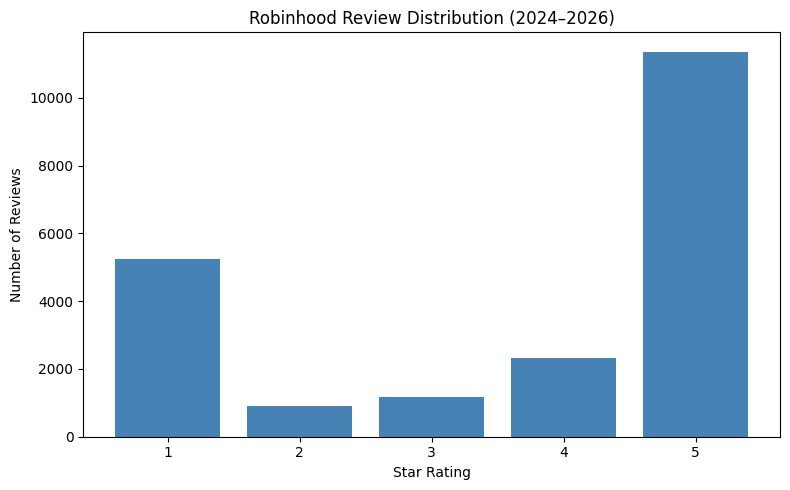

score
1     5245
2      909
3     1162
4     2315
5    11369
Name: count, dtype: int64

Average rating: 3.65


In [12]:
import matplotlib.pyplot as plt

# Count how many reviews have each star rating (1-5)
score_counts = df['score'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(score_counts.index, score_counts.values, color='steelblue')
plt.xlabel('Star Rating')
plt.ylabel('Number of Reviews')
plt.title('Robinhood Review Distribution (2024–2026)')
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

print(score_counts)
print(f"\nAverage rating: {df['score'].mean():.2f}")

2026-06-09 12:01:42,236 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:01:42,236 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


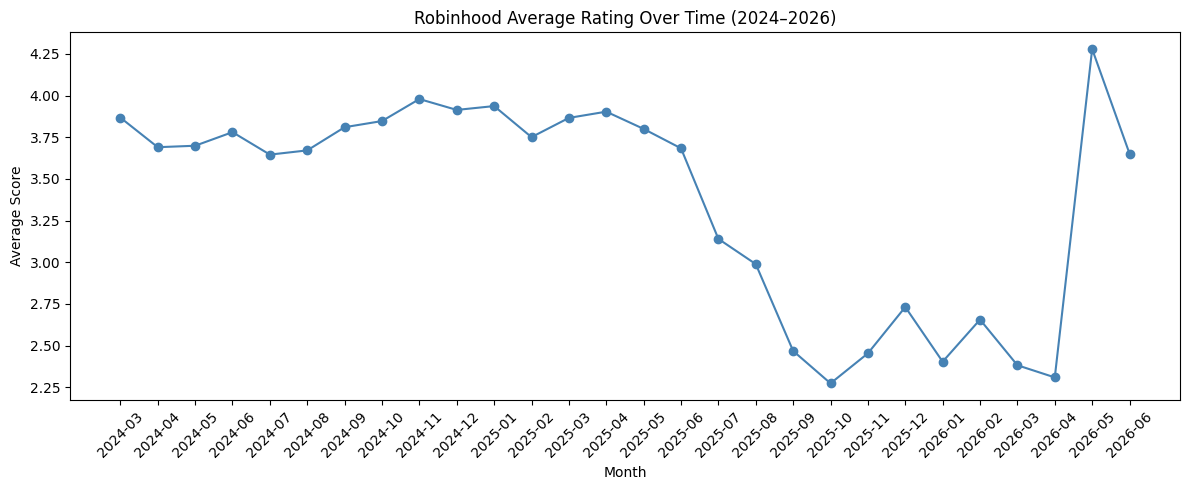

In [13]:
# Convert 'at' column to datetime format so Python understands it as a date
df['at'] = pd.to_datetime(df['at'])

# Extract just the year and month from the full timestamp
# e.g. 2024-03-15 becomes 2024-03 
df['month'] = df['at'].dt.to_period('M')

# Group all reviews by month and calculate the average score for each month
monthly_score = df.groupby('month')['score'].mean()

# Plot it as a line chart
plt.figure(figsize=(12, 5))
plt.plot(monthly_score.index.astype(str), monthly_score.values, marker='o', color='steelblue')
plt.xlabel('Month')
plt.ylabel('Average Score')
plt.title('Robinhood Average Rating Over Time (2024–2026)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [14]:
print(df.groupby('month')['score'].count())

month
2024-03     537
2024-04     707
2024-05     877
2024-06     811
2024-07     796
2024-08     754
2024-09     648
2024-10     870
2024-11    1441
2024-12    1545
2025-01    1508
2025-02     866
2025-03    1239
2025-04    1015
2025-05     940
2025-06     594
2025-07     443
2025-08     446
2025-09     432
2025-10     443
2025-11     289
2025-12     320
2026-01     315
2026-02     305
2026-03     351
2026-04     340
2026-05    1927
2026-06     241
Freq: M, Name: score, dtype: int64


2026-06-09 12:01:42,675 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:01:42,680 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


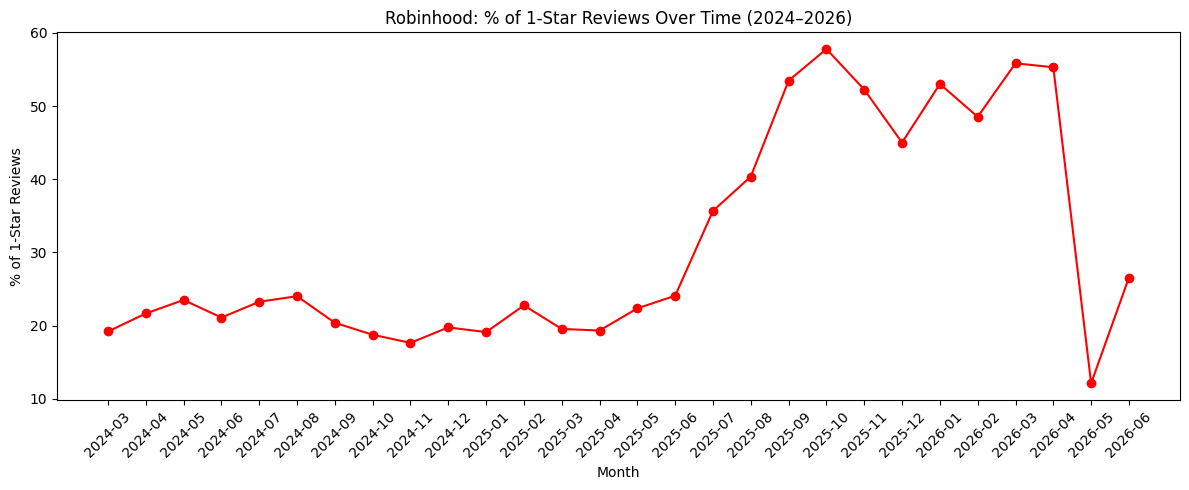

In [15]:
# Count total reviews per month
total_per_month = df.groupby('month')['score'].count()

# Count only 1-star reviews per month
# We first filter the dataframe to only rows where score == 1
# Then count how many there are per month
one_star_per_month = df[df['score'] == 1].groupby('month')['score'].count()

# Divide 1-star count by total count to get the proportion
# multiply by 100 to make it a percentage
one_star_pct = (one_star_per_month / total_per_month * 100).fillna(0)

# Plot it
plt.figure(figsize=(12, 5))
plt.plot(one_star_pct.index.astype(str), one_star_pct.values, marker='o', color='red')
plt.xlabel('Month')
plt.ylabel('% of 1-Star Reviews')
plt.title('Robinhood: % of 1-Star Reviews Over Time (2024–2026)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [16]:
! pip install vaderSentiment


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Create the analyzer object
# VADER is specifically designed for social media and short text like reviews
analyzer = SentimentIntensityAnalyzer()

# This applies sentiment scoring to every review in the 'content' column
# compound score ranges from -1 (most negative) to +1 (most positive)
# anything below -0.05 is negative, above 0.05 is positive
df['sentiment_score'] = df['content'].apply(
    lambda x: analyzer.polarity_scores(str(x))['compound']
)

# Label each review as positive, negative or neutral based on the score
df['sentiment_label'] = df['sentiment_score'].apply(
    lambda x: 'negative' if x < -0.05 else ('positive' if x > 0.05 else 'neutral')
)

print(df['sentiment_label'].value_counts())

sentiment_label
positive    13900
negative     4152
neutral      2948
Name: count, dtype: int64


In [18]:
# Filter only 1-star reviews
negative_reviews = df[df['score'] == 1]['content']

print(f"Total 1-star reviews: {len(negative_reviews)}")
print("\n--- Sample of 10 negative reviews ---\n")
for review in negative_reviews.sample(10, random_state=42):
    print(f"• {review[:200]}")
    print()

Total 1-star reviews: 5245

--- Sample of 10 negative reviews ---

• This app sucks on android. Can't even gain access to my old account because it keeps saying that I need to update the app to proceed but it's already updated... makes no sense.

• They have no customer service. They locked my account and will not release it. No humans work here except for negative reviews they write the EXACT same thing to anyone who writes a bad review. Don't 

• support is not here. can't sign in and they keep sending me around in circles.

• Worst customer service imaginable. Won't contact you if you need to verify your identity, sends worthless emails that direct you to the app you can't log into. Hope the company goes out of business.

• New robinhood menu is ugly. No one asked for this. I don't want to see all the tabs at the top.

• Definitely didn't download this one.

• You know why

• this app has pissed me off so many times

• Funny how when I buy a stock or 2 the damn company I bought from

In [20]:
# Drop any reviews where content is empty or null
negative_reviews = df[df['score'] == 1]['content'].dropna()
negative_reviews = negative_reviews[negative_reviews.str.strip() != '']

print(f"Clean 1-star reviews: {len(negative_reviews)}")

Clean 1-star reviews: 5244


In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# Join all 1-star reviews into one collection
# max_features=30 means we only want the 30 most common words
# stop_words='english' removes common words like 'the', 'a', 'is'
vectorizer = CountVectorizer(max_features=30, stop_words='english')
word_matrix = vectorizer.fit_transform(negative_reviews)

# Sum up how many times each word appears
word_freq = dict(zip(
    vectorizer.get_feature_names_out(),
    word_matrix.toarray().sum(axis=0)
))

# Sort by frequency
word_freq_sorted = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)

for word, count in word_freq_sorted:
    print(f"{word}: {count}")

app: 2419
account: 1992
money: 1584
robinhood: 1156
support: 680
don: 678
customer: 677
use: 652
just: 646
service: 550
phone: 511
time: 480
like: 425
update: 420
let: 391
email: 390
ve: 377
help: 364
want: 364
crypto: 359
won: 352
sell: 349
stock: 348
number: 341
trying: 335
buy: 329
company: 326
trading: 321
stocks: 317
make: 314


In [22]:
! pip install wordcloud


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


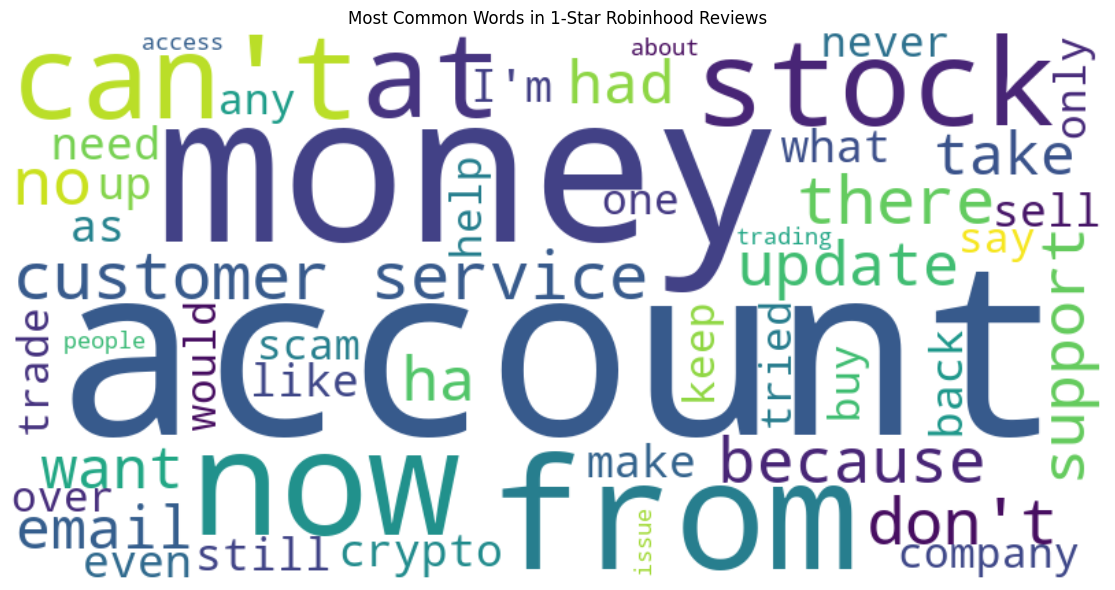

In [31]:
from wordcloud import WordCloud

# Join all 1-star review text into one big string
text = ' '.join(negative_reviews)

# Create the word cloud
# bigger the word = more frequent it appears
# stopwords removes common words like 'the', 'a', 'is'
# background_color makes it white so it's clean
wordcloud = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    stopwords={
    'robinhood', 'app', 'just', 'don', 'use', 'will', 'get',
    'the', 'and', 'it', 'this', 'that', 'for', 'not', 'my',
    'they', 'you', 'have', 'with', 'but', 'all', 'can', 'so',
    'or', 'are', 'your', 'their', 'out', 'do', 'be', 'when',
    'in', 'to', 'of', 'a', 'i', 'me', 'is', 'on', 'if', 'after',
    'then', 'them', 'was', 'been', 'time', 'day', 'trying', 'cant'
},
    max_words=50
).generate(text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in 1-Star Robinhood Reviews')
plt.tight_layout()
plt.show()

In [32]:
competitors = ['fidelity', 'schwab', 'webull', 'etrade', 'td ameritrade', 'charles schwab']

# Check if each review mentions a competitor
df['competitor_mention'] = df['content'].str.lower().apply(
    lambda x: any(c in str(x) for c in competitors)
)

# How many reviews mention competitors?
print(f"Reviews mentioning competitors: {df['competitor_mention'].sum()}")
print(f"As % of all reviews: {df['competitor_mention'].mean()*100:.1f}%")

# Which competitors are mentioned most?
for c in competitors:
    count = df['content'].str.lower().str.contains(c).sum()
    print(f"{c}: {count} mentions")

Reviews mentioning competitors: 262
As % of all reviews: 1.2%
fidelity: 98 mentions
schwab: 51 mentions
webull: 110 mentions
etrade: 22 mentions
td ameritrade: 6 mentions
charles schwab: 11 mentions


In [33]:
! pip install gensim pyLDAvis

   ---------------------------------------- 0.0/24.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.4 MB ? eta -:--:--
   - -------------------------------------- 0.8/24.4 MB 2.1 MB/s eta 0:00:12
   -- ------------------------------------- 1.3/24.4 MB 2.2 MB/s eta 0:00:11
   -- ------------------------------------- 1.6/24.4 MB 2.1 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/24.4 MB 2.1 MB/s eta 0:00:11
   ---- ----------------------------------- 2.6/24.4 MB 2.2 MB/s eta 0:00:11
   ---- ----------------------------------- 2.9/24.4 MB 2.1 MB/s eta 0:00:11
   ----- ---------------------------------- 3.4/24.4 MB 2.1 MB/s eta 0:00:10
   ------ --------------------------------- 3.9/24.4 MB 2.1 MB/s eta 0:00:10
   ------- -------------------------------- 4.5/24.4 MB 2.2 MB/s eta 0:00:10
   ------- -------------------------------- 4.7/24.4 MB 2.1 MB/s eta 0:00:10
   -------- ------------------------------- 5.0/24.4 MB 2.1 MB/s eta 0:00:10
   --------- 


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
import gensim
from gensim import corpora
from gensim.utils import simple_preprocess
from gensim.parsing.preprocessing import STOPWORDS
import warnings
warnings.filterwarnings('ignore')

# We'll work only with 1-star reviews since that's where our thesis lives
one_star_reviews = df[df['score'] == 1]['content'].dropna()

# This converts each review into a list of meaningful words
# simple_preprocess lowercases and removes punctuation
# We also remove common english stopwords plus domain-specific ones
custom_stopwords = STOPWORDS.union({
    'robinhood', 'app', 'just', 'use', 'get', 'got', 'like',
    'really', 'even', 'know', 'think', 'want', 'going', 'said',
    'say', 'way', 'time', 'now', 'still', 'back', 'ever', 'never'
})

# Tokenize — split each review into individual words, remove stopwords
def preprocess(text):
    return [word for word in simple_preprocess(str(text)) 
            if word not in custom_stopwords and len(word) > 3]

# Apply preprocessing to all reviews
processed_reviews = [preprocess(review) for review in one_star_reviews]

# Create a dictionary — maps every unique word to an ID number
dictionary = corpora.Dictionary(processed_reviews)

# Filter out words that appear in less than 5 reviews or more than 50% of reviews
dictionary.filter_extremes(no_below=5, no_above=0.5)

# Create bag of words — converts each review to (word_id, frequency) pairs
corpus = [dictionary.doc2bow(review) for review in processed_reviews]

print(f"Vocabulary size: {len(dictionary)}")
print(f"Number of reviews processed: {len(corpus)}")

2026-06-09 12:34:20,071 [INFO] gensim.corpora.dictionary - adding document #0 to Dictionary<0 unique tokens: []>
2026-06-09 12:34:20,170 [INFO] gensim.corpora.dictionary - built Dictionary<6485 unique tokens: ['compared', 'contracts', 'disappointing', 'dishonest', 'goes']...> from 5244 documents (total 65487 corpus positions)
2026-06-09 12:34:20,170 [INFO] gensim.utils - Dictionary lifecycle event {'msg': "built Dictionary<6485 unique tokens: ['compared', 'contracts', 'disappointing', 'dishonest', 'goes']...> from 5244 documents (total 65487 corpus positions)", 'datetime': '2026-06-09T12:34:20.170044', 'gensim': '4.4.0', 'python': '3.12.7 (tags/v3.12.7:0b05ead, Oct  1 2024, 03:06:41) [MSC v.1941 64 bit (AMD64)]', 'platform': 'Windows-11-10.0.26200-SP0', 'event': 'created'}
2026-06-09 12:34:20,186 [INFO] gensim.corpora.dictionary - discarding 4724 tokens: [('websites', 3), ('ether', 1), ('ethereum', 2), ('etheruem', 1), ('keys', 4), ('priva', 1), ('simplicity', 4), ('surprised', 4), ('a

Vocabulary size: 1761
Number of reviews processed: 5244


In [35]:
# Build the LDA model
# num_topics=5 means we want 5 distinct complaint categories
# passes=10 means the model reads through the data 10 times to improve accuracy
# random_state=42 makes results reproducible

lda_model = gensim.models.LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=5,
    passes=10,
    random_state=42
)

# Print the top words for each topic
print("--- Top words per topic ---\n")
for idx, topic in lda_model.print_topics(num_words=8):
    print(f"Topic {idx}: {topic}")
    print()

2026-06-09 12:34:55,754 [INFO] gensim.models.ldamodel - using symmetric alpha at 0.2
2026-06-09 12:34:55,766 [INFO] gensim.models.ldamodel - using symmetric eta at 0.2
2026-06-09 12:34:55,817 [INFO] gensim.models.ldamodel - using serial LDA version on this node
2026-06-09 12:34:55,877 [INFO] gensim.models.ldamodel - running online (multi-pass) LDA training, 5 topics, 10 passes over the supplied corpus of 5244 documents, updating model once every 2000 documents, evaluating perplexity every 5244 documents, iterating 50x with a convergence threshold of 0.001000
2026-06-09 12:34:55,881 [INFO] gensim.models.ldamodel - PROGRESS: pass 0, at document #2000/5244
2026-06-09 12:34:56,622 [INFO] gensim.models.ldamodel - merging changes from 2000 documents into a model of 5244 documents
2026-06-09 12:34:56,634 [INFO] gensim.models.ldamodel - topic #0 (0.200): 0.043*"account" + 0.019*"money" + 0.013*"access" + 0.013*"customer" + 0.012*"support" + 0.009*"service" + 0.008*"help" + 0.008*"sell" + 0.008

--- Top words per topic ---

Topic 0: 0.062*"account" + 0.030*"phone" + 0.023*"support" + 0.022*"email" + 0.021*"number" + 0.017*"help" + 0.016*"customer" + 0.016*"update"

Topic 1: 0.034*"customer" + 0.029*"service" + 0.025*"support" + 0.019*"account" + 0.016*"terrible" + 0.013*"horrible" + 0.013*"gold" + 0.011*"hood"

Topic 2: 0.021*"good" + 0.015*"open" + 0.013*"customer" + 0.013*"company" + 0.012*"working" + 0.012*"service" + 0.011*"sucks" + 0.011*"away"

Topic 3: 0.084*"money" + 0.044*"account" + 0.016*"scam" + 0.013*"transfer" + 0.013*"funds" + 0.012*"bank" + 0.010*"days" + 0.009*"company"

Topic 4: 0.029*"sell" + 0.026*"trading" + 0.023*"stock" + 0.022*"market" + 0.021*"price" + 0.015*"trade" + 0.014*"options" + 0.014*"order"



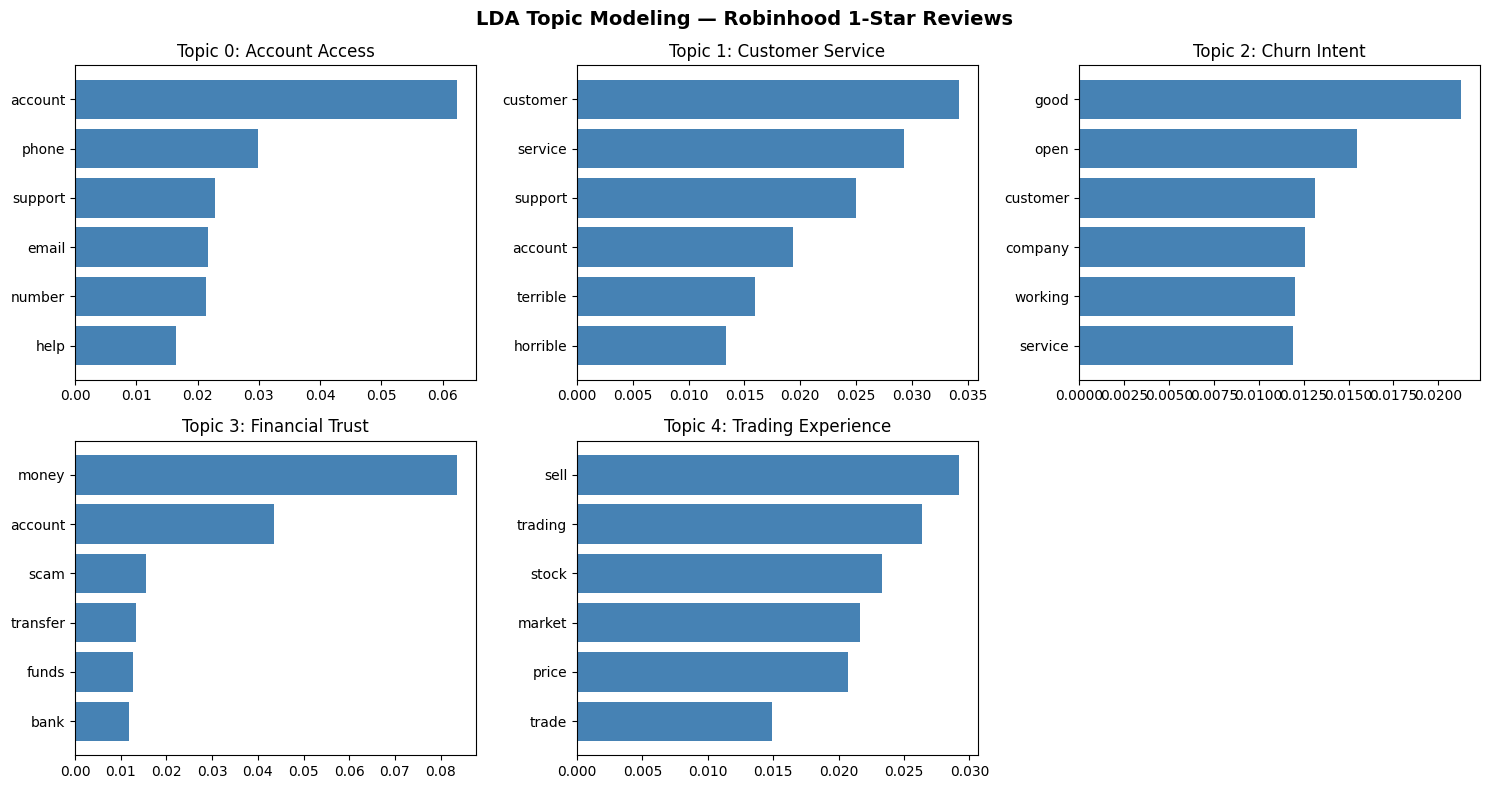

In [37]:
# Create a bar chart showing top words for each topic
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

topic_labels = [
    'Account Access', 
    'Customer Service', 
    'Churn Intent',
    'Financial Trust', 
    'Trading Experience'
]

for idx in range(5):
    # Get top 6 words and their weights for this topic
    top_words = dict(lda_model.show_topic(idx, topn=6))
    words = list(top_words.keys())
    weights = list(top_words.values())
    
    axes[idx].barh(words, weights, color='steelblue')
    axes[idx].set_title(f'Topic {idx}: {topic_labels[idx]}')
    axes[idx].invert_yaxis()

# Hide the empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('LDA Topic Modeling — Robinhood 1-Star Reviews', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [38]:
# This function finds which topic a review belongs to most strongly
def get_dominant_topic(bow):
    # get_document_topics returns a list of (topic_id, probability) pairs
    # we pick the topic with the highest probability
    topics = lda_model.get_document_topics(bow)
    if topics:
        return max(topics, key=lambda x: x[1])[0]
    return None

# Apply to all 1-star reviews
# We need the corpus we built earlier — each review as bag of words
dominant_topics = [get_dominant_topic(bow) for bow in corpus]

# Add topic assignments back to the dataframe
one_star_df = df[df['score'] == 1].dropna(subset=['content']).copy()
one_star_df['dominant_topic'] = dominant_topics

# Map topic numbers to readable labels
topic_map = {
    0: 'Account Access',
    1: 'Customer Service', 
    2: 'Churn Intent',
    3: 'Financial Trust',
    4: 'Trading Experience'
}
one_star_df['topic_label'] = one_star_df['dominant_topic'].map(topic_map)

# Check distribution
print(one_star_df['topic_label'].value_counts())

topic_label
Account Access        1516
Financial Trust       1398
Trading Experience     942
Customer Service       804
Churn Intent           584
Name: count, dtype: int64


2026-06-09 12:56:23,374 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:56:23,397 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:56:23,416 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:56:23,423 [INFO] matplotlib.category - Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-06-09 12:56:23,437 [INF

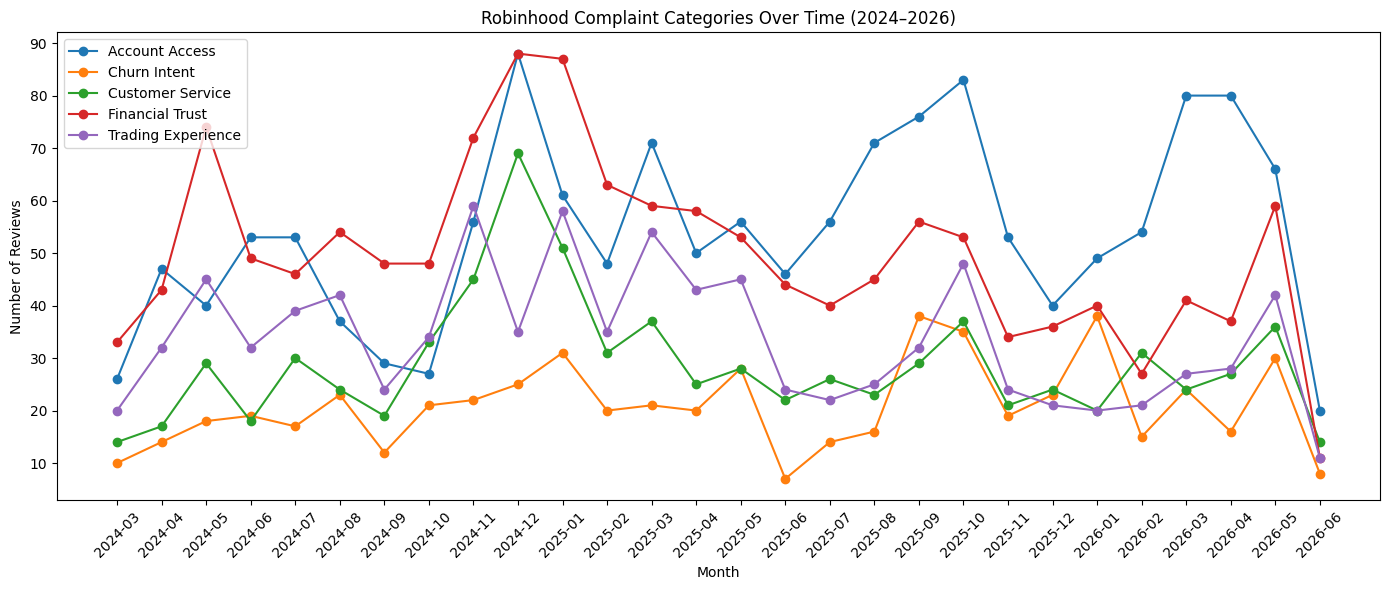

In [39]:
# Add month column to our 1-star dataframe
one_star_df['month'] = pd.to_datetime(one_star_df['at']).dt.to_period('M')

# Count reviews per topic per month
topic_trend = one_star_df.groupby(['month', 'topic_label']).size().unstack(fill_value=0)

# Plot each topic as a line
plt.figure(figsize=(14, 6))
for topic in topic_trend.columns:
    plt.plot(topic_trend.index.astype(str), topic_trend[topic], marker='o', label=topic)

plt.xlabel('Month')
plt.ylabel('Number of Reviews')
plt.title('Robinhood Complaint Categories Over Time (2024–2026)')
plt.xticks(rotation=45)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [40]:
# Sort 1-star reviews by thumbs up count
# This surfaces complaints that resonated most with other users
top_thumbs = one_star_df.nlargest(20, 'thumbsUpCount')[
    ['content', 'score', 'thumbsUpCount', 'at', 'topic_label']
]

print("--- Top 20 Most Upvoted Negative Reviews ---\n")
for _, row in top_thumbs.iterrows():
    print(f"👍 {row['thumbsUpCount']} | Topic: {row['topic_label']} | {row['at'].date()}")
    print(f"   {str(row['content'])[:200]}")
    print()

--- Top 20 Most Upvoted Negative Reviews ---

👍 834 | Topic: Financial Trust | 2024-08-13
   Please do not waste your time or money with this app! No such thing as "no fees".

👍 616 | Topic: Trading Experience | 2025-10-08
   Robinhood app crashes if I'm on option simulated returns for more than a few seconds.

👍 530 | Topic: Trading Experience | 2026-02-26
   your app is broken. I can't put in any orders to buy stocks or crypto... the keyboard to put in an order doesn't come up no matter what I do. you broke your app...

👍 443 | Topic: Trading Experience | 2024-05-25
   Absolutely hate that I'm forced to use dark theme for all crypto. At that point why even pretend to let us customize our theme?

👍 442 | Topic: Trading Experience | 2026-04-22
   The app sets you up for failure by inducing its users to make mistakes. UPDATE: app got worse, when creating a new order the app is intentionally deleting the digits when trying to update your target 

👍 409 | Topic: Account Access | 2025-05-1

                    total_thumbs  avg_thumbs  review_count
topic_label                                               
Trading Experience          6050    6.422505           942
Churn Intent                2337    4.001712           584
Financial Trust             4390    3.140200          1398
Customer Service            2405    2.991294           804
Account Access              4497    2.966359          1516


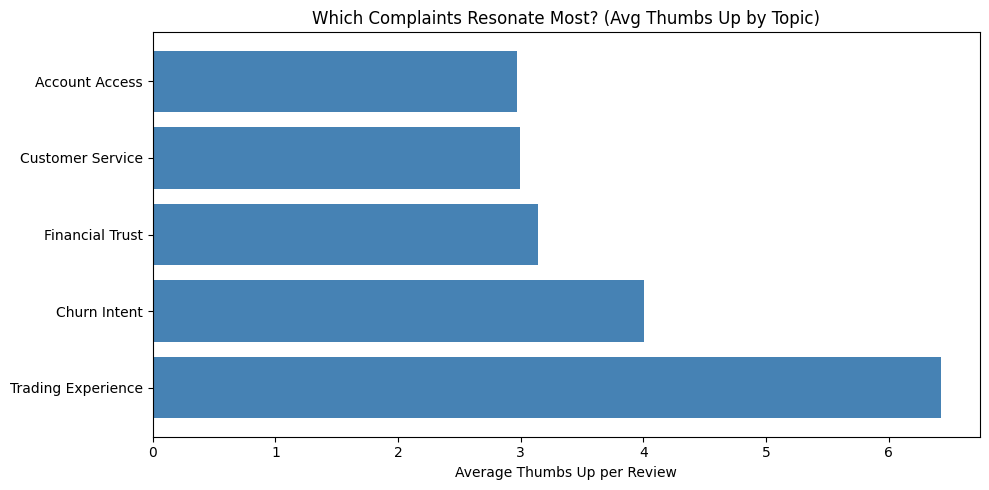

In [41]:
# Calculate average thumbs up per topic
# This tells us which complaint category resonates most broadly
thumbs_by_topic = one_star_df.groupby('topic_label')['thumbsUpCount'].agg(
    total_thumbs='sum',
    avg_thumbs='mean',
    review_count='count'
).sort_values('avg_thumbs', ascending=False)

print(thumbs_by_topic)

# Plot average thumbs up by topic
plt.figure(figsize=(10, 5))
plt.barh(
    thumbs_by_topic.index,
    thumbs_by_topic['avg_thumbs'],
    color='steelblue'
)
plt.xlabel('Average Thumbs Up per Review')
plt.title('Which Complaints Resonate Most? (Avg Thumbs Up by Topic)')
plt.tight_layout()
plt.show()

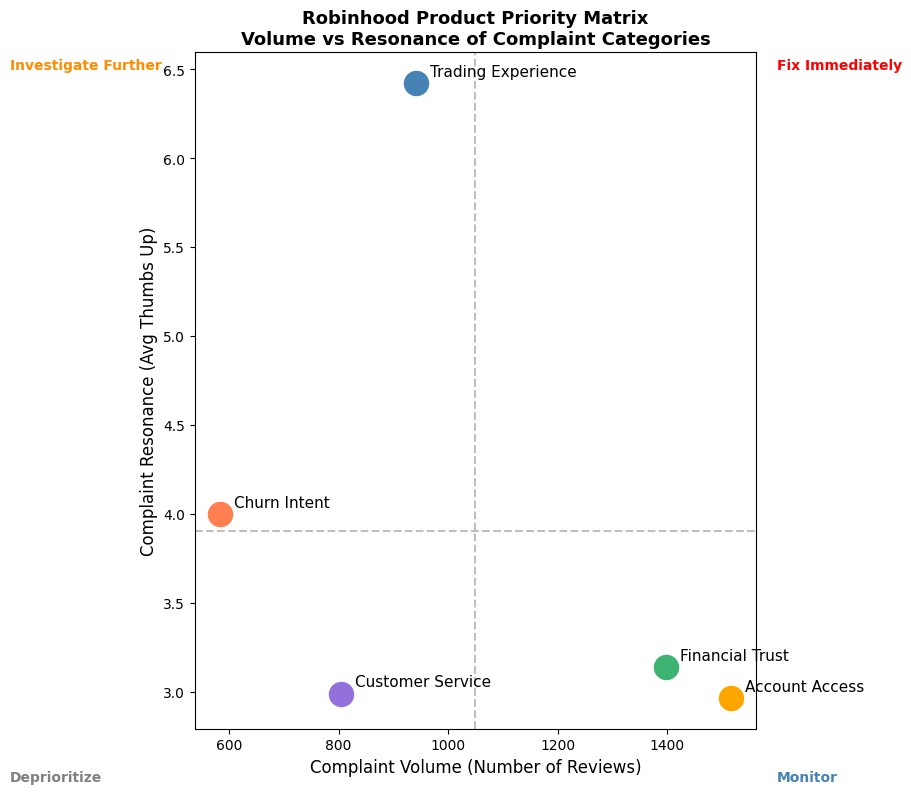

In [42]:
# We already have this data from the thumbs analysis
# Let's build the priority matrix

fig, ax = plt.subplots(figsize=(10, 8))

# Data points for each topic
topics = thumbs_by_topic.index.tolist()
x = thumbs_by_topic['review_count'].tolist()  # Volume
y = thumbs_by_topic['avg_thumbs'].tolist()    # Resonance

# Plot each topic as a scatter point
colors = ['steelblue', 'coral', 'mediumseagreen', 'mediumpurple', 'orange']
for i, topic in enumerate(topics):
    ax.scatter(x[i], y[i], s=300, color=colors[i], zorder=5)
    ax.annotate(topic, (x[i], y[i]), 
                textcoords="offset points", 
                xytext=(10, 5), 
                fontsize=11)

# Add quadrant lines at the median of each axis
median_x = sum(x) / len(x)
median_y = sum(y) / len(y)
ax.axvline(x=median_x, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=median_y, color='gray', linestyle='--', alpha=0.5)

# Label quadrants
ax.text(1600, 6.5, 'Fix Immediately', fontsize=10, color='red', fontweight='bold')
ax.text(200, 6.5, 'Investigate Further', fontsize=10, color='darkorange', fontweight='bold')
ax.text(1600, 2.5, 'Monitor', fontsize=10, color='steelblue', fontweight='bold')
ax.text(200, 2.5, 'Deprioritize', fontsize=10, color='gray', fontweight='bold')

ax.set_xlabel('Complaint Volume (Number of Reviews)', fontsize=12)
ax.set_ylabel('Complaint Resonance (Avg Thumbs Up)', fontsize=12)
ax.set_title('Robinhood Product Priority Matrix\nVolume vs Resonance of Complaint Categories', 
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()